**Name: Kaustubh Aswale**  
**Roll No: 69** 
**Assignment 7**

1. Extract Sample document and apply following document preprocessing methods:
Tokenization, POS Tagging, stop words removal, Stemming and Lemmatization.
2. Create representation of documents by calculating Term Frequency and Inverse
DocumentFrequency.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
import re

pd.options.display.max_columns = None
sns.set(style='whitegrid', palette='muted')

In [2]:
# Download necessary NLTK data
import nltk
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('wordnet_ic', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag

print('NLTK data ready.')

NLTK data ready.


In [3]:
# Create sample documents
sample_documents = [
    "Natural language processing is a subfield of linguistics, computer science, and artificial intelligence concerned with the interactions between computers and human language.",
    "Machine learning is the study of computer algorithms that improve automatically through experience.",
    "Data science combines statistics, programming, and domain expertise to extract insights from data.",
    "Artificial intelligence aims to create machines that can perform tasks that typically require human intelligence.",
    "Text mining is the process of deriving high-quality information from text.",
    "Sentiment analysis determines the emotional tone behind a series of words.",
    "Named entity recognition identifies and classifies named entities in text.",
    "Topic modeling discovers abstract topics in a collection of documents.",
    "Word embeddings represent words as vectors in a continuous vector space.",
    "Chatbots use natural language processing to simulate human conversation."
]

# Create DataFrame
df = pd.DataFrame({'document': sample_documents})
df.head()

,document
0,Natural language processing is a subfield of l...
1,Machine learning is the study of computer algo...
2,"Data science combines statistics, programming,..."
3,Artificial intelligence aims to create machine...
4,Text mining is the process of deriving high-qu...


In [4]:
# EDA:
print('Shape:', df.shape)
print('Size:', df.size)

Shape: (10, 1)
Size: 10


In [5]:
print('\nInfo:')
df.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   document  10 non-null     object
dtypes: object(1)
memory usage: 208.0+ bytes


In [6]:
print('\nDescribe (text lengths):')
df['text_length'] = df['document'].apply(len)
df['text_length'].describe()


Describe (text lengths):


count     10.000000
mean      91.900000
std       32.219559
min       70.000000
25%       72.500000
50%       74.000000
75%       98.750000
max      173.000000
Name: text_length, dtype: float64

In [7]:
print('\nSample documents:')
for i, doc in enumerate(df['document'][:3]):
    print(f'Doc {i+1}: {doc[:100]}...')


Sample documents:
Doc 1: Natural language processing is a subfield of linguistics, computer science, and artificial intellige...
Doc 2: Machine learning is the study of computer algorithms that improve automatically through experience....
Doc 3: Data science combines statistics, programming, and domain expertise to extract insights from data....


In [8]:
# Insert rows with null/empty values in between the dataset
null_rows = pd.DataFrame([
    {'document': 'This is a sample document with some content.'},
    {'document': ''},  
    {'document': np.nan}
])

insert_position = 3
df_with_null = pd.concat([df.iloc[:insert_position], null_rows, df.iloc[insert_position:]]).reset_index(drop=True)

print('New shape with inserted rows:', df_with_null.shape)
df_with_null.head(10)

New shape with inserted rows: (13, 2)


,document,text_length
0,Natural language processing is a subfield of l...,173.0
1,Machine learning is the study of computer algo...,99.0
2,"Data science combines statistics, programming,...",98.0
3,This is a sample document with some content.,NaN
4,,NaN
5,NaN,NaN
6,Artificial intelligence aims to create machine...,113.0
7,Text mining is the process of deriving high-qu...,74.0
8,Sentiment analysis determines the emotional to...,74.0
9,Named entity recognition identifies and classi...,74.0


In [9]:
print('\nNull counts before removal:')
print(df_with_null.isnull().sum())
print('\nEmpty documents:', (df_with_null['document'] == '').sum())


Null counts before removal:
document       1
text_length    3
dtype: int64

Empty documents: 1


In [10]:
# Remove null/empty values and confirm
df_no_null = df_with_null.dropna().copy()
df_no_null = df_no_null[df_no_null['document'] != ''].reset_index(drop=True)
print('Shape after cleanup:', df_no_null.shape)
print('\nNull counts after cleanup:\n', df_no_null.isnull().sum(), sep="")
print('\nEmpty documents after cleanup:', (df_no_null['document'] == '').sum())

Shape after cleanup: (10, 2)

Null counts after cleanup:
document       0
text_length    0
dtype: int64

Empty documents after cleanup: 0


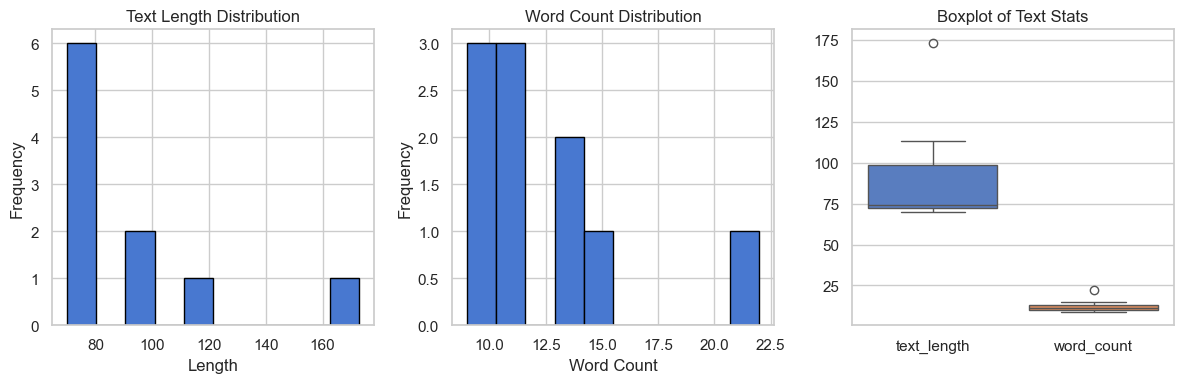

In [11]:
# Visualizations: text length distribution, word count distribution
df_no_null['word_count'] = df_no_null['document'].apply(lambda x: len(x.split()))
df_no_null['text_length'] = df_no_null['document'].apply(len)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(df_no_null['text_length'], bins=10, edgecolor='black')
plt.title('Text Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(df_no_null['word_count'], bins=10, edgecolor='black')
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=df_no_null[['text_length', 'word_count']])
plt.title('Boxplot of Text Stats')

plt.tight_layout()
plt.show()

Shape after outlier cleanup: (9, 3)


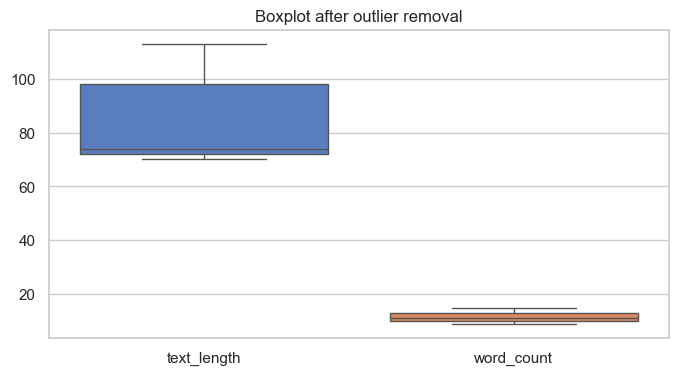

In [12]:
# Outlier detection and removal (based on text length)
df_clean = df_no_null.copy()

# Remove outliers using IQR on text_length
q1 = df_clean['text_length'].quantile(0.25)
q3 = df_clean['text_length'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
df_clean = df_clean[(df_clean['text_length'] >= lower) & (df_clean['text_length'] <= upper)]

print('Shape after outlier cleanup:', df_clean.shape)

plt.figure(figsize=(8,4))
sns.boxplot(data=df_clean[['text_length', 'word_count']])
plt.title('Boxplot after outlier removal')
plt.show()

In [13]:
# Category checks (no categories in this dataset, but we can add document types)
df_clean['doc_type'] = ['technical'] * 5 + ['general'] * 4 
print('Document types:')
print(df_clean['doc_type'].value_counts())

Document types:
doc_type
technical    5
general      4
Name: count, dtype: int64


In [14]:
df_clean.head()

,document,text_length,word_count,doc_type
1,Machine learning is the study of computer algo...,99,13,technical
2,"Data science combines statistics, programming,...",98,13,technical
3,Artificial intelligence aims to create machine...,113,15,technical
4,Text mining is the process of deriving high-qu...,74,11,technical
5,Sentiment analysis determines the emotional to...,74,11,technical


In [15]:
# Convert to numeric
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clean['doc_type_num'] = le.fit_transform(df_clean['doc_type'])
print('Type mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

Type mapping: {'general': np.int64(0), 'technical': np.int64(1)}


In [16]:
# Preprocessing: Clean text (lowercase, remove punctuation)
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

df_clean['cleaned_text'] = df_clean['document'].apply(clean_text)
df_clean.head()

,document,text_length,word_count,doc_type,doc_type_num,cleaned_text
1,Machine learning is the study of computer algo...,99,13,technical,1,machine learning is the study of computer algo...
2,"Data science combines statistics, programming,...",98,13,technical,1,data science combines statistics programming a...
3,Artificial intelligence aims to create machine...,113,15,technical,1,artificial intelligence aims to create machine...
4,Text mining is the process of deriving high-qu...,74,11,technical,1,text mining is the process of deriving highqua...
5,Sentiment analysis determines the emotional to...,74,11,technical,1,sentiment analysis determines the emotional to...


Task 1: Document preprocessing methods

In [17]:
# Select first document for demonstration
sample_doc = df_clean['cleaned_text'].iloc[0]
print('Original sample document:')
print(sample_doc)

Original sample document:
machine learning is the study of computer algorithms that improve automatically through experience


In [18]:
# Tokenization
tokens = word_tokenize(sample_doc)
print('Tokenization:')
print(tokens)

Tokenization:
['machine', 'learning', 'is', 'the', 'study', 'of', 'computer', 'algorithms', 'that', 'improve', 'automatically', 'through', 'experience']


In [19]:
# POS Tagging
pos_tags = pos_tag(tokens)
print('POS Tagging:')
print(pos_tags)

POS Tagging:
[('machine', 'NN'), ('learning', 'NN'), ('is', 'VBZ'), ('the', 'DT'), ('study', 'NN'), ('of', 'IN'), ('computer', 'NN'), ('algorithms', 'NN'), ('that', 'WDT'), ('improve', 'VBP'), ('automatically', 'RB'), ('through', 'IN'), ('experience', 'NN')]


In [20]:
# Stop words removal
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word not in stop_words]
print('After stop words removal:')
print(filtered_tokens)

After stop words removal:
['machine', 'learning', 'study', 'computer', 'algorithms', 'improve', 'automatically', 'experience']


In [21]:
# Stemming
stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]
print('Stemming:')
print(stemmed_tokens)

Stemming:
['machin', 'learn', 'studi', 'comput', 'algorithm', 'improv', 'automat', 'experi']


In [22]:
# Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]
print('Lemmatization:')
print(lemmatized_tokens)

Lemmatization:
['machine', 'learning', 'study', 'computer', 'algorithm', 'improve', 'automatically', 'experience']


In [23]:
# Task 2: TF-IDF representation
documents = df_clean['cleaned_text'].tolist()

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=100)
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)

# Get feature names (terms)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Convert to DataFrame for better visualization
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
print('TF-IDF Matrix shape:', tfidf_matrix.shape)
print('Top 10 terms:', feature_names[:10])
tfidf_df

TF-IDF Matrix shape: (9, 67)
Top 10 terms: ['abstract' 'aims' 'algorithms' 'analysis' 'artificial' 'automatically'
 'chatbots' 'classifies' 'collection' 'combines']


,abstract,aims,algorithms,analysis,artificial,automatically,chatbots,classifies,collection,combines,computer,continuous,conversation,create,data,deriving,determines,discovers,documents,domain,embeddings,emotional,entities,entity,experience,expertise,extract,highquality,human,identifies,improve,information,insights,intelligence,language,learning,machine,machines,mining,modeling,named,natural,perform,process,processing,programming,recognition,represent,require,science,sentiment,series,simulate,space,statistics,study,tasks,text,tone,topic,topics,typically,use,vector,vectors,word,words
0,0.000000,0.000000,0.353553,0.000000,0.000000,0.353553,0.000000,0.000000,0.000000,0.000000,0.353553,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.353553,0.000000,0.000000,0.000000,0.000000,0.000000,0.353553,0.000000,0.000000,0.000000,0.000000,0.353553,0.353553,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.353553,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.288675,0.000000,0.000000,0.000000,0.000000,0.57735,0.000000,0.000000,0.000000,0.000000,0.288675,0.000000,0.000000,0.000000,0.000000,0.000000,0.288675,0.288675,0.000000,0.000000,0.000000,0.000000,0.000000,0.288675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.288675,0.000000,0.000000,0.000000,0.288675,0.000000,0.000000,0.000000,0.000000,0.288675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.280459,0.000000,0.000000,0.280459,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.280459,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.236880,0.000000,0.000000,0.000000,0.000000,0.560918,0.000000,0.000000,0.000000,0.280459,0.000000,0.000000,0.000000,0.000000,0.280459,0.000000,0.000000,0.000000,0.000000,0.000000,0.280459,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.280459,0.000000,0.000000,0.000000,0.000000,0.280459,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.356836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.356836,0.000000,0.000000,0.000000,0.356836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.356836,0.000000,0.000000,0.000000,0.000000,0.356836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.602778,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.385949,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.385949,0.000000,0.000000,0.000000,0.000000,0.385949,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.385949,0.385949,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.385949,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.325978
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.320859,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.320859,0.320859,0.000000,0.000000,0.000000,0.000000,0.000000,0.320859,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.641719,0.000000,0.000000,0.0

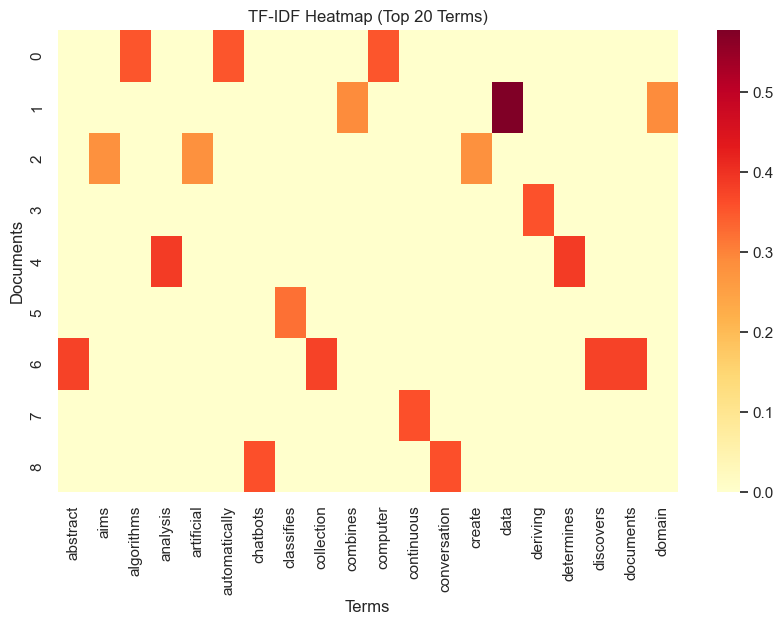

In [24]:
# Visual insights: TF-IDF heatmap for top terms
top_terms = feature_names[:20] 
tfidf_top = tfidf_df[top_terms]

plt.figure(figsize=(10, 6))
sns.heatmap(tfidf_top, annot=False, cmap='YlOrRd', cbar=True)
plt.title('TF-IDF Heatmap (Top 20 Terms)')
plt.xlabel('Terms')
plt.ylabel('Documents')
plt.show()

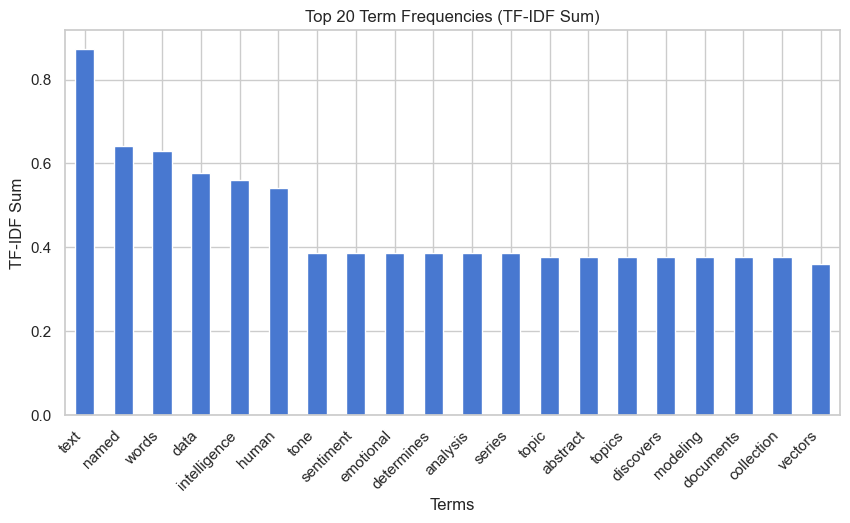

In [25]:
# Term frequency analysis
term_frequencies = tfidf_df.sum(axis=0).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
term_frequencies.head(20).plot(kind='bar')
plt.title('Top 20 Term Frequencies (TF-IDF Sum)')
plt.xlabel('Terms')
plt.ylabel('TF-IDF Sum')
plt.xticks(rotation=45, ha='right')
plt.show()